<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Isadora Madrid


### **Link de repositorio de GitHub:** https://github.com/isadoramadrid/MDS7202.git


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [1]:
import pandas as pd

df = pd.read_csv("Precios Casas RM.csv")

In [3]:
from pandas.api.types import is_numeric_dtype
from pandas.api.types import is_datetime64_any_dtype, is_timedelta64_dtype
import plotly.express as px
import missingno as msno

from IPython.display import display, Markdown

def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown('# Analisis columnas'))
    display(Markdown('## Descripcion variables'))
    display(df.describe())
    for col in df.columns:

        serie = df[col].copy()

        profile = pd.Series(dtype='object')
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = (
                str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            )
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = (
                str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            )
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = (
            str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        )
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = (
            str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        )
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):

            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(
                sampled_serie, marginal="box", title=f"{serie.name}", nbins=48
            )

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")
        
        else:
            count = (
                serie.value_counts()[0:100]
                .reset_index()
                .rename(columns = {'count': 'Count'})
            )
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f'## {serie.name} Profile'))
        display(profile)
        fig.show()

    display(Markdown('# Analisis de nulos'))
    display(Markdown('## Nulos por columna'))
    display(df.isna().sum())
    display(Markdown('## Visualizacion de nulos'))
    msno.matrix(df)
    display(Markdown('## Correlacion de nulidad'))
    msno.heatmap(df)


# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62360 bytes
dtype: object

...

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

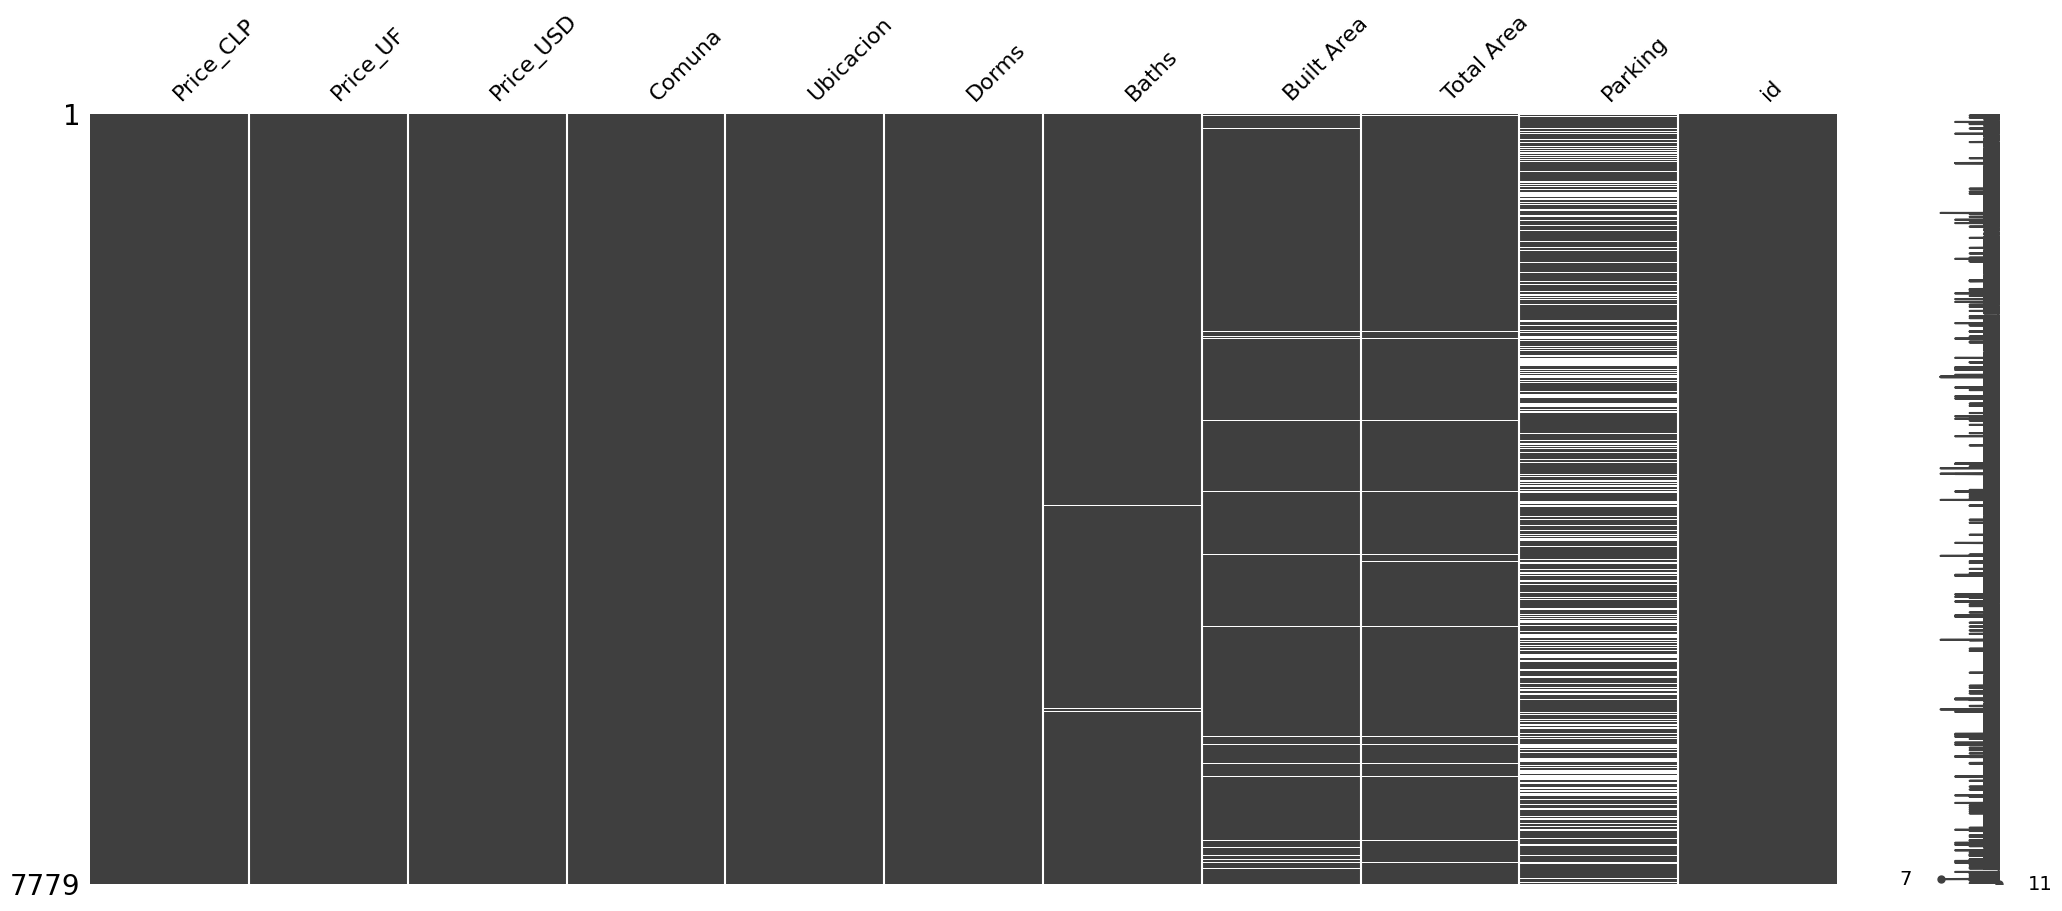

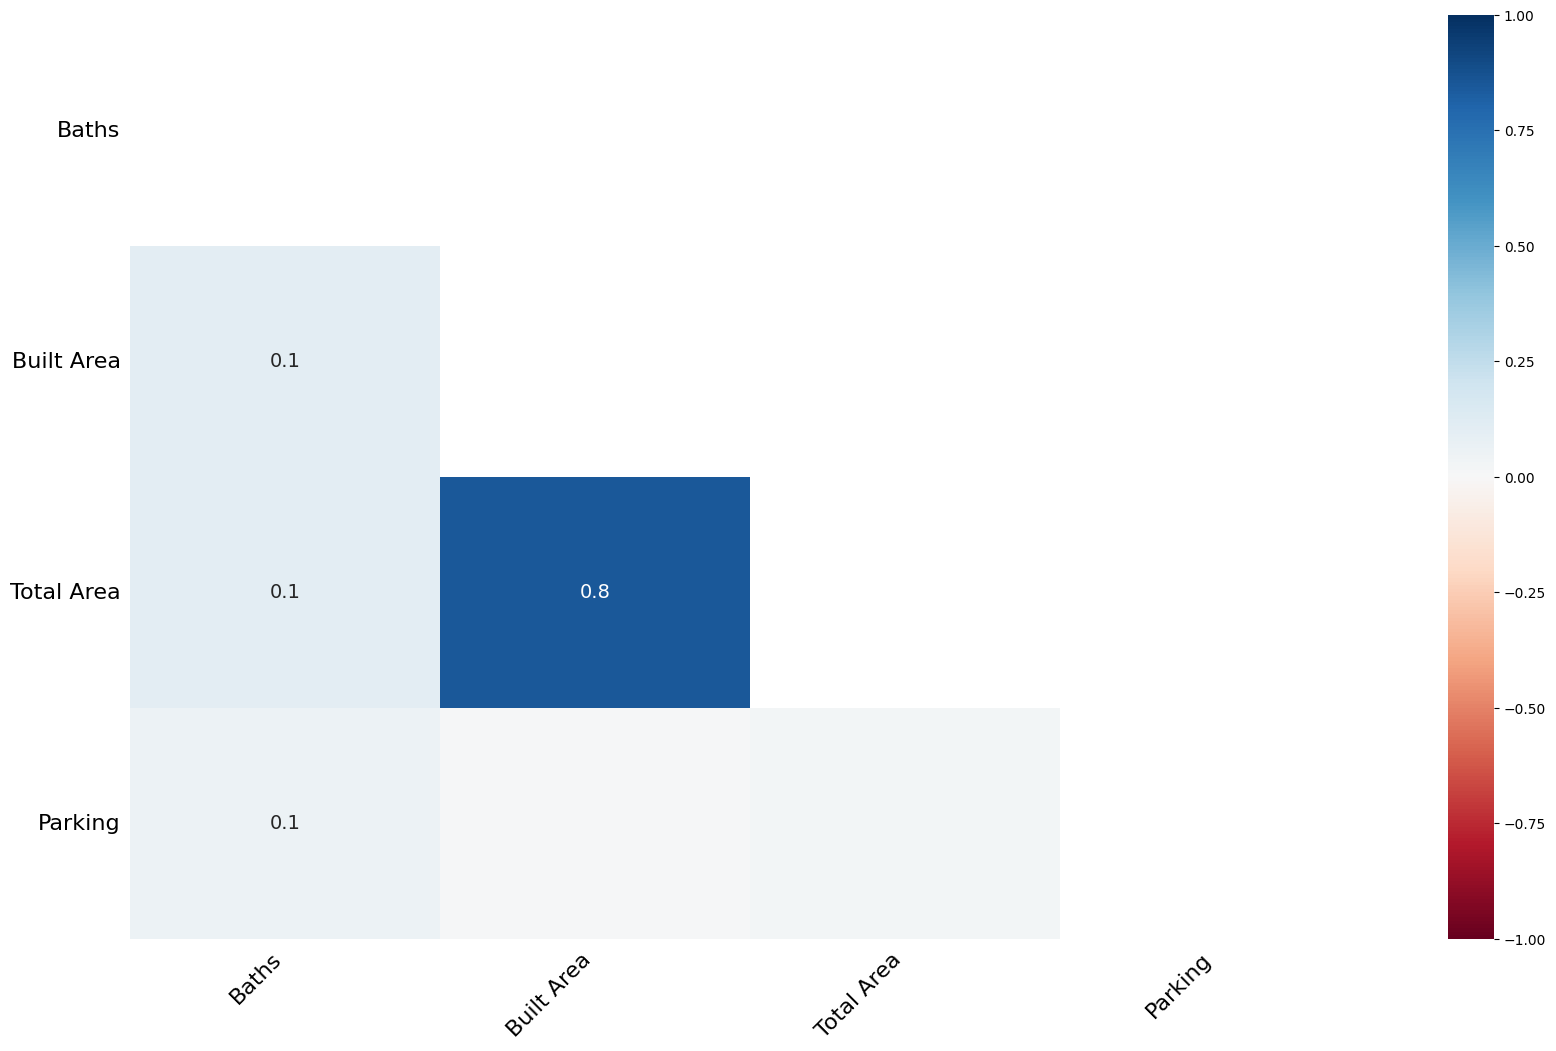

In [4]:
# Inserte acá su código
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

1.- La variable objetivo Price_CLP presenta una distribución asimétrica hacia la derecha. Esto significa que la mayoría de las propiedades se concentran en precios relativamente bajos o medios, pero existen algunas propiedades con precios extremadamente altos.

Según el análisis descriptivo, el precio mínimo observado es de aproximadamente $2.085 CLP, lo cual parece ser un valor anómalo o mal registrado. La mediana es de aproximadamente $205.000.000 CLP, mientras que el percentil 75 está cerca de $491.142.000 CLP. El valor máximo llega a aproximadamente $5.516.450.000 CLP, lo que confirma la presencia de valores muy altos.

2.- Las variables categóricas principales son Comuna y Ubicacion. La variable Comuna sí parece útil para el modelo, porque la comuna influye directamente en el precio de una vivienda. No es lo mismo una propiedad ubicada en Puente Alto, Las Condes, Providencia o Lo Barnechea. Por lo tanto, esta variable puede entregar información relevante sobre diferencias territoriales y de mercado.

La variable Ubicacion, en cambio, tiene demasiados valores únicos: aproximadamente 6620 ubicaciones distintas para 7779 observaciones. Esto indica que tiene una cardinalidad muy alta, por lo que puede ser difícil usarla directamente en un modelo. Podría generar muchas categorías con muy pocas observaciones, lo que puede afectar el aprendizaje del modelo. Sin embargo, podría ser útil si se procesa o agrupa, por ejemplo, extrayendo información de barrio, sector o coordenadas si estuvieran disponibles.

Como features categóricas usaría principalmente Comuna. No utilizaría directamente variables como Price_UF o Price_USD como features para predecir Price_CLP, porque representan el mismo precio en otras unidades y generarían fuga de información.

3.-  Las variables con valores nulos son Baths, Built Area, Total Area y Parking.

En el caso de Baths, hay 65 valores nulos, equivalentes a aproximadamente 0,84% del dataset. Según la documentación, esta variable representa cuántos baños tiene la casa. Como el dataset contiene solo casas en venta, lo esperable es que toda casa tenga al menos un baño. Además, dentro de los valores observados el mínimo es 1, no 0. Por lo tanto, estos nulos probablemente corresponden a datos no disponibles o mal extraídos durante el web scraping, no a que la vivienda no tenga baños.

En Built Area, hay 246 valores nulos, equivalentes a aproximadamente 3,16%. Esta variable indica los metros cuadrados construidos de la casa. Como toda casa debería tener algún nivel de superficie construida, estos nulos no parecen significar “no aplica”. Más bien, probablemente corresponden a información no disponible, omitida en el aviso o extraída incorrectamente desde la página.

En Total Area, hay 208 valores nulos, equivalentes a aproximadamente 2,67%. Esta variable representa los metros cuadrados totales de la propiedad. Dado que el dataset no incluye terrenos, sino casas en venta, esta información debería existir para cada propiedad. Por lo tanto, estos nulos también parecen corresponder a datos no disponibles o problemas de extracción, no a un valor real.

En Parking, hay 2290 valores nulos, equivalentes a aproximadamente 29,44%, que es el mayor porcentaje de datos faltantes. Esta variable indica cuántos estacionamientos tiene la casa. En este caso, la interpretación es distinta, porque sí es posible que una casa no tenga estacionamiento. Además, en los valores observados el mínimo es 1 y no aparecen valores 0. Esto sugiere que los nulos podrían representar propiedades con 0 estacionamientos. Por eso, para esta variable podría tener sentido reemplazar los nulos por 0, aunque también es posible que algunos casos sean simplemente datos no informados.


4.- No, no utilizaría la columna id como feature para entrenar el modelo. Esta columna parece ser solo un identificador único de cada observación o publicación, por lo que no representa una característica real de la vivienda. Incluir id podría hacer que el modelo aprenda patrones artificiales relacionados con el orden o el código de publicación, pero no con el precio real de la propiedad.

5.- Sí, se observan varios valores atípicos en el dataset.
En Price_CLP, hay precios extremadamente altos, llegando a más de $5.500 millones de pesos, mientras que la mediana es de aproximadamente $205 millones. También existe un precio mínimo de solo $2.085 CLP, lo cual no tiene sentido para una vivienda y probablemente corresponde a un error de registro.

También hay valores atípicos en variables como Dorms, donde el máximo es 27 dormitorios, y en Baths, donde el máximo es 29 baños. Estos valores son muy altos para viviendas comunes y podrían representar propiedades especiales, errores o publicaciones mal registradas.

En Built Area, el máximo es 120.000 m², y en Total Area, el máximo es 678.000 m², valores extremadamente grandes en comparación con la mayoría de las observaciones. Además, en Parking, aparece un máximo de 1269 estacionamientos, lo cual podría considerarse atípico o posiblemente un error.

### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd

def preparacion_de_datos():
    # Cargar dataset
    df = pd.read_csv("Precios Casas RM.csv")
    
    # Eliminar duplicados
    # Uso id para detectar publicaciones repetidas, pero luego no lo uso como feature
    df = df.drop_duplicates(subset=["id"], keep="first")
    
    # Tratamiento de nulos
    # Parking: si está nulo, se interpreta como 0 estacionamientos
    df["Parking"] = df["Parking"].fillna(0)
    
    # Baths, Built Area y Total Area: si están nulos, falta información relevante,
    # por lo tanto se eliminan esas filas
    df = df.dropna(subset=["Baths", "Built Area", "Total Area"])
    
    # Eliminar valores atípicos muy poco razonables
    # Criterio conservador basado en lo observado en el EDA
    df = df[df["Price_CLP"] >= 10_000_000]
    df = df[df["Dorms"] <= 15]
    df = df[df["Baths"] <= 15]
    df = df[df["Built Area"] <= 5000]
    df = df[df["Total Area"] <= 20000]
    df = df[df["Parking"] <= 20]
    
    # Separar target
    y = df["Price_CLP"]
    
    # eleccionar features
    X = df[[
        "Comuna",
        "Dorms",
        "Baths",
        "Built Area",
        "Total Area",
        "Parking"
    ]]
    
    # Holdout: separar train y test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    
    return X_train, X_test, y_train, y_test

In [9]:
X_train, X_test, y_train, y_test = preparacion_de_datos()

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5907, 6), (1477, 6), (5907,), (1477,))

Justificar su preparación de datos.
- ¿Qué columnas usó para eliminar nulos y por qué?
- ¿Qué proporción de los datos usó para test y por qué?

En la preparación de datos se eliminaron duplicados usando la columna id, ya que esta identifica cada publicación. Sin embargo, id no se usa como variable predictora porque no representa una característica real de la vivienda.

Para los valores nulos, se imputó Parking con 0, porque es razonable interpretar que una casa sin información de estacionamientos puede no tener estacionamiento. En cambio, se eliminaron las filas con nulos en Baths, Built Area y Total Area, ya que esas variables representan información básica de una casa y sus nulos parecen deberse a datos no disponibles o errores del scraping.

También se eliminaron algunos valores atípicos muy poco razonables, como precios extremadamente bajos, cantidades excesivas de baños, dormitorios, estacionamientos o superficies muy grandes. Esto se hizo porque la documentación advierte que, al venir de web scraping, puede haber información ingresada incorrectamente.

Finalmente, se usó un 80% entrenamiento y 20% test. Esta proporción permite entrenar el modelo con la mayoría de los datos, pero dejando una parte separada para evaluar su desempeño en observaciones que el modelo no vio durante el entrenamiento.

### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Columnas numéricas que sí usaremos como features
numeric_features = ["Dorms", "Baths", "Built Area", "Total Area", "Parking"]

# Columna categórica que sí usaremos
categorical_features = ["Comuna"]

# Preprocesamiento para variables numéricas:
# Imputar nulos con la mediana
# Escalar variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesamiento para variables categóricas:
# Imputar nulos con la categoría más frecuente
# Aplicar one hot encoding
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot)
])

# ColumnTransformer final
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [13]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

X_train_preprocessed.shape, X_test_preprocessed.shape

((5907, 56), (1477, 56))

Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?
- ¿Por qué escaló los features de esta forma?
- ¿Qué valor(es) usó para imputación y por qué?

Para el preprocesamiento se mantuvieron como variables numéricas Dorms, Baths, Built Area, Total Area y Parking, ya que representan características propias de la vivienda y pueden estar relacionadas con el precio. Además, se mantuvo la variable Comuna, porque la ubicación comunal es una variable relevante para explicar diferencias de precio entre propiedades.

Se eliminaron columnas como Price_UF y Price_USD, porque representan el mismo precio objetivo en otras monedas o unidade. También se eliminó id, porque es solo un identificador de la publicación y no una característica real de la vivienda. Además, no se usó Ubicacion directamente porque tiene demasiadas categorías distintas.

Las variables numéricas se escalaron usando StandardScaler, ya que están en unidades muy distintas. Por ejemplo, Dorms y Baths tienen valores pequeños, mientras que Built Area y Total Area pueden tomar valores mucho más grandes. Escalar permite que estas variables queden en una escala comparable para los modelos.

Para la imputación de variables numéricas se usó la mediana, porque es más robusta frente a valores atípicos que el promedio. En el caso de la variable categórica Comuna, se usó la categoría más frecuente en caso de existir algún nulo. Finalmente, Comuna se transformó con OneHotEncoder, ya que los modelos necesitan variables numéricas y no pueden trabajar directamente con texto.

### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Dorms', 'Baths',
                                                   'Built Area', 'Total Area',
                                                   'Parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Comuna'])])),
                ('model', Ridge())])

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [15]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(pipeline, x_train, x_test, y_train, y_test):
    # Predicciones en entrenamiento
    y_train_pred = pipeline.predict(x_train)
    
    # Predicciones en test
    y_test_pred = pipeline.predict(x_test)
    
    # Métricas en entrenamiento
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)
    
    # Métricas en test
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    print("Resultados en TRAIN")
    print(f"RMSE: {rmse_train:,.0f}")
    print(f"MAE:  {mae_train:,.0f}")
    print(f"R²:   {r2_train:.4f}")
    
    print("\nResultados en TEST")
    print(f"RMSE: {rmse_test:,.0f}")
    print(f"MAE:  {mae_test:,.0f}")
    print(f"R²:   {r2_test:.4f}")
    
    return {
        "rmse_train": rmse_train,
        "mae_train": mae_train,
        "r2_train": r2_train,
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "r2_test": r2_test
    }

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [16]:
def complete_pipeline_v1():
    # Preparación de datos
    X_train, X_test, y_train, y_test = preparacion_de_datos()
    
    # Entrenamiento del pipeline
    pipeline.fit(X_train, y_train)
    
    # Evaluación del modelo
    results = evaluate_model(
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    return pipeline, results

In [17]:
pipeline_v1, results_v1 = complete_pipeline_v1()

Resultados en TRAIN
RMSE: 210,574,493
MAE:  114,040,861
R²:   0.7108

Resultados en TEST
RMSE: 194,781,850
MAE:  112,500,546
R²:   0.7213


3. Responder las siguientes preguntas (0.15 ptos c/u)
- ¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)
- ¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?
- ¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error
- Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique

1.- Podemos considerar que le modelo tiene un buen desempeño, aunque todavía presenta errores importantes en pesos chilenos. En datos de test obtuvo un RMSE de $194.781.850, lo que indica que, considerando especialmente los errores grandes, el modelo puede equivocarse en torno a 195 millones de pesos. Esta métrica es alta, pero tiene sentido considerando que los precios de viviendas tienen mucha variabilidad y existen propiedades muy caras.

El MAE en test fue de $112.500.546, lo que significa que, en promedio, el modelo se equivoca aproximadamente en 112 millones de pesos. Esta métrica es más fácil de interpretar que el RMSE, porque representa el error promedio absoluto sin castigar tanto los errores extremos.

El R² en test fue de 0.7213, lo que indica que el modelo logra explicar aproximadamente un 72% de la variabilidad del precio. Esto es un resultado aceptable para una primera versión del modelo, especialmente considerando que se usó un modelo lineal y variables relativamente simples como comuna, dormitorios, baños, superficie y estacionamientos.

2.- Si se elige un modelo pensando en optimizar el RMSE, se estaría priorizando reducir los errores grandes. Esto es útil cuando nos preocupa equivocarnos mucho en propiedades muy caras o casos extremos, ya que el RMSE castiga más fuerte los errores grandes. Si se elige un modelo pensando en optimizar el MAE, se estaría buscando reducir el error promedio de manera más estable. Esta métrica es menos sensible a valores atípicos, por lo que puede ser más representativa del error típico que cometería el modelo en una propiedad común. Si se elige un modelo pensando en optimizar el R², se estaría buscando explicar la mayor proporción posible de la variabilidad del precio. Sin embargo, un R² alto no siempre significa que el error en pesos sea bajo, por lo que conviene mirarlo junto con RMSE y MAE.

3.- El desempeño del modelo puede estar afectado por varias fuentes de error. Primero, el dataset proviene de web scraping, por lo que puede contener información mal ingresada, valores extremos o errores en las publicaciones. Tambien podemos considerar que el modelo usa pocas variables para explicar el precio. Aunque variables como comuna, superficie, baños, dormitorios y estacionamientos son importantes, faltan otros factores relevantes, como estado de la propiedad, antigüedad, cercanía al metro, seguridad del sector, orientación, conectividad o atributos específicos del barrio. Además, utilizamos un modelo lineal con regularización Ridge. Este modelo es estable y fácil de interpretar, pero puede no capturar relaciones más complejas entre las variables. Además, algunas variables categóricas como Ubicacion no fueron usadas directamente porque tenían demasiadas categorías, pero podrían contener información relevante sobre sectores específicos dentro de cada comuna.

4.- No parece haber sobreajuste. Las métricas de entrenamiento y test son bastante parecidas.
En entrenamiento, el modelo obtuvo un RMSE de $210.574.493, un MAE de $114.040.861 y un R² de 0.7108. En test, obtuvo un RMSE de $194.781.850, un MAE de $112.500.546 y un R² de 0.7213.
De hecho, las métricas en test son levemente mejores que en entrenamiento. Como el desempeño en test no empeora respecto al entrenamiento, no hay evidencia clara de sobreajuste. El modelo parece generalizar de forma razonable a datos no vistos.

## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd

def preparacion_de_datos_2():
    # 1. Cargar datasets
    df = pd.read_csv("Precios Casas RM.csv")
    df_comunas = pd.read_excel("ingresos_por_comuna_2024.xlsx")
    
    # 2. Limpiar espacios en nombres de columnas
    df.columns = df.columns.str.strip()
    df_comunas.columns = df_comunas.columns.str.strip()
    
    # 3. Seleccionar columnas necesarias del dataset adicional
    df_comunas = df_comunas[[
        "Nombre comuna",
        "Porcentaje de personas en situacion de pobreza de ingresos 2024"
    ]]
    
    # 4. Renombrar columnas para poder cruzar con el dataset principal
    df_comunas = df_comunas.rename(columns={
        "Nombre comuna": "Comuna",
        "Porcentaje de personas en situacion de pobreza de ingresos 2024": "pobreza_2024"
    })
    
    # 5. Limpiar texto de comuna para evitar errores por espacios
    df["Comuna"] = df["Comuna"].astype(str).str.strip()
    df_comunas["Comuna"] = df_comunas["Comuna"].astype(str).str.strip()
    
    # 6. Merge por comuna
    df = df.merge(df_comunas, on="Comuna", how="left")
    
    # 7. Eliminar duplicados usando id
    df = df.drop_duplicates(subset=["id"], keep="first")
    
    # 8. Tratamiento de nulos
    df["Parking"] = df["Parking"].fillna(0)
    
    df = df.dropna(subset=[
        "Baths",
        "Built Area",
        "Total Area",
        "pobreza_2024"
    ])
    
    # 9. Eliminar valores atípicos usando el mismo criterio anterior
    df = df[df["Price_CLP"] >= 10_000_000]
    df = df[df["Dorms"] <= 15]
    df = df[df["Baths"] <= 15]
    df = df[df["Built Area"] <= 5000]
    df = df[df["Total Area"] <= 20000]
    df = df[df["Parking"] <= 20]
    
    # 10. Separar target
    y = df["Price_CLP"]
    
    # 11. Seleccionar features incluyendo pobreza_2024
    X = df[[
        "Comuna",
        "Dorms",
        "Baths",
        "Built Area",
        "Total Area",
        "Parking",
        "pobreza_2024"
    ]]
    
    # 12. Holdout
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    
    return X_train, X_test, y_train, y_test

In [24]:
X_train_2, X_test_2, y_train_2, y_test_2 = preparacion_de_datos_2()

X_train_2.head()

,Comuna,Dorms,Baths,Built Area,Total Area,Parking,pobreza_2024
6553,PuenteAlto,2,1.0,90.0,90.0,2.0,0.138264
1677,Maipú,4,1.0,105.0,294.0,4.0,0.120385
2401,Pudahuel,3,3.0,165.0,300.0,2.0,0.154393
3379,Ñuñoa,5,3.0,205.0,250.0,0.0,0.057072
4052,Lampa,5,4.0,286.0,5048.0,0.0,0.158160


### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

# Variables numéricas, ahora incluyendo la nueva variable socioeconómica
numeric_features_v2 = [
    "Dorms",
    "Baths",
    "Built Area",
    "Total Area",
    "Parking",
    "pobreza_2024"
]

# Variable categórica
categorical_features_v2 = ["Comuna"]

# Preprocesamiento para variables numéricas
numeric_transformer_v2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocesamiento para variable categórica con Target Encoding
categorical_transformer_v2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_encoder", TargetEncoder(target_type="continuous", random_state=42))
])

# ColumnTransformer versión 2
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_v2, numeric_features_v2),
        ("cat", categorical_transformer_v2, categorical_features_v2)
    ],
    remainder="drop"
)

# Pipeline versión 2
pipeline_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor_v2),
    ("model", Ridge(alpha=1.0))
])

# Función completa versión 2
def complete_pipeline_v2():
    X_train_2, X_test_2, y_train_2, y_test_2 = preparacion_de_datos_2()
    
    pipeline_v2.fit(X_train_2, y_train_2)
    
    results_v2 = evaluate_model(
        pipeline_v2,
        X_train_2,
        X_test_2,
        y_train_2,
        y_test_2
    )
    
    return pipeline_v2, results_v2

In [26]:
pipeline_v2, results_v2 = complete_pipeline_v2()

Resultados en TRAIN
RMSE: 216,162,768
MAE:  119,634,607
R²:   0.6952

Resultados en TEST
RMSE: 196,233,557
MAE:  114,960,298
R²:   0.7172


c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.36374e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [27]:
import pandas as pd

# Ejecutar pipeline versión 1
pipeline_v1, results_v1 = complete_pipeline_v1()

print("\n" + "="*50 + "\n")

# Ejecutar pipeline versión 2
pipeline_v2, results_v2 = complete_pipeline_v2()

# Crear tabla comparativa
comparacion = pd.DataFrame({
    "Modelo v1": results_v1,
    "Modelo v2": results_v2
}).T

comparacion

Resultados en TRAIN
RMSE: 210,574,493
MAE:  114,040,861
R²:   0.7108

Resultados en TEST
RMSE: 194,781,850
MAE:  112,500,546
R²:   0.7213


Resultados en TRAIN
RMSE: 216,162,768
MAE:  119,634,607
R²:   0.6952

Resultados en TEST
RMSE: 196,233,557
MAE:  114,960,298
R²:   0.7172


c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.36374e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,rmse_train,mae_train,r2_train,rmse_test,mae_test,r2_test
Modelo v1,2.105745e+08,1.140409e+08,0.710764,1.947819e+08,1.125005e+08,0.721330
Modelo v2,2.161628e+08,1.196346e+08,0.695208,1.962336e+08,1.149603e+08,0.717161


El modelo que tuvo mejor desempeño fue el Modelo v1. Al comparar las métricas en test, el Modelo v1 obtuvo un RMSE de 194.781.850, mientras que el Modelo v2 obtuvo 196.233.557. Como el RMSE es menor en v1, este modelo comete errores grandes levemente menores.

También en MAE, el Modelo v1 fue mejor, con un error promedio de 112.500.546, frente a 114.960.298 del Modelo v2. Esto indica que, en promedio, el Modelo v1 se equivoca un poco menos al predecir el precio de las viviendas.

El R² también fue mayor en el Modelo v1, 0.7213 versus 0.7172 en el Modelo v2. Esto significa que el Modelo v1 explica una proporción ligeramente mayor de la variabilidad del precio.

### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

El Modelo v1 obtuvo mejores resultados que el Modelo v2, aunque la diferencia fue pequeña. Esto se observa porque en test tuvo menor RMSE y menor MAE, además de un R² levemente mayor. Es decir, predijo mejor los precios en datos no vistos.

Una razón es que el uso de One Hot Encoding en Comuna pudo capturar mejor las diferencias entre comunas. En cambio, el Target Encoding reemplaza cada comuna por un promedio del precio, lo que puede simplificar demasiado la información y perder diferencias importantes dentro de cada comuna. 
Una segunda razón es que la nueva variable pobreza_2024 puede no haber agregado mucha información adicional. Al ser una variable a nivel comunal, probablemente está muy relacionada con la misma variable Comuna, por lo que no aporta tanto al modelo. Además, el precio de una vivienda depende de muchos otros factores más específicos, como se menciono anteriormente.
Respecto al sobreajuste, no se observa un sobreajuste fuerte, porque las métricas de entrenamiento y test son bastante similares en ambos modelos. De hecho, el Modelo v2 no mejora en test, pero tampoco parece tener un desempeño muy alto en entrenamiento y muy bajo en test.

2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [28]:
# Obtener los modelos entrenados desde cada pipeline
modelo_v1 = pipeline_v1.steps[-1][1]
modelo_v2 = pipeline_v2.steps[-1][1]

# Cantidad de parámetros según el largo de coef_
n_parametros_v1 = len(modelo_v1.coef_)
n_parametros_v2 = len(modelo_v2.coef_)

print("Cantidad de parámetros Modelo v1:", n_parametros_v1)
print("Cantidad de parámetros Modelo v2:", n_parametros_v2)

Cantidad de parámetros Modelo v1: 56
Cantidad de parámetros Modelo v2: 7


El Modelo v1 tiene 56 parámetros, mientras que el Modelo v2 tiene solo 7 parámetros. Esto muestra que el segundo pipeline es mucho menos complejo.

La diferencia se explica principalmente por el tratamiento de la variable Comuna. En el Modelo v1 se usó One Hot Encoding, lo que crea muchas columnas nuevas, una por cada comuna. En cambio, en el Modelo v2 se usó Target Encoding, que reemplaza cada comuna por un solo valor numérico asociado al promedio del precio en esa comuna. Por eso el número de parámetros baja mucho.

Sin embargo, al comparar las métricas, el Modelo v1 tuvo un desempeño levemente mejor, menor RMSE, menor MAE y mayor R² en test. Esto indica que, aunque el Modelo v2 es más simple, esa simplificación no mejoró la predicción.

El segundo pipeline reduce la complejidad del modelo, pero probablemente perdió información específica de cada comuna. No se observa un sobreajuste fuerte en ninguno de los dos modelos, porque las métricas de train y test son parecidas.